# 02.1 — Standard K-means (Baseline)

**Algoritma:** K-means standar dengan inisialisasi **K-means++**  
**Tujuan:** Baseline sederhana tanpa optimasi metaheuristik

| Parameter | Nilai |
|-----------|-------|
| K (cluster) | 6 |
| Init | K-means++ |
| n_init | 30 (restarts) |
| max_iter | 300 |

**Output:** `data/Labeled/hasildata_kmeans-standard.csv`


In [25]:
# ============================================================
# Import
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_SEED  = 42
K_OPTIMAL    = 6
ALGO_NAME    = 'kmeans-standard'
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

CLUSTER_COLORS = ['#E63946','#2A9D8F','#E9C46A','#264653','#F4A261','#A8DADC']
CLUSTER_LABELS = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']

print(f'Algoritma: Standard K-means | K={K_OPTIMAL}')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Algoritma: Standard K-means | K=6
NumPy  : 2.3.3
Pandas : 2.3.3


In [26]:
# ============================================================
# Load Data
# ============================================================
df_pca    = pd.read_csv('../data/processed/customer_features_pca.csv', index_col='CustomerID')
df_scaled = pd.read_csv('../data/processed/customer_features_scaled.csv', index_col='CustomerID')
df_raw    = pd.read_csv('../data/processed/customer_features_raw.csv', index_col='CustomerID')

print(f'Data PCA (6 PC)       : {df_pca.shape}    — kolom: {list(df_pca.columns)}')
print(f'Data Scaled (11 fitur): {df_scaled.shape} — kolom: {list(df_scaled.columns)}')
print(f'Data Raw (11 fitur)   : {df_raw.shape}    — kolom: {list(df_raw.columns)}')
print(f'\nJumlah pelanggan: {len(df_pca):,}')

X_pca = df_pca.values
X_scaled = df_scaled.values   
X_raw    = df_raw.values       

print(f'\nX_pca shape   : {X_pca.shape}')
print(f'X_scaled shape: {X_scaled.shape}')

Data PCA (6 PC)       : (4335, 6)    — kolom: ['PCA 1', 'PCA 2', 'PCA 3', 'PCA 4', 'PCA 5', 'PCA 6']
Data Scaled (11 fitur): (4335, 11) — kolom: ['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10', 'Var11']
Data Raw (11 fitur)   : (4335, 11)    — kolom: ['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10', 'Var11']

Jumlah pelanggan: 4,335

X_pca shape   : (4335, 6)
X_scaled shape: (4335, 11)


## 1. Jalankan Algoritma

In [27]:
# ============================================================
# Standard K-means
# ============================================================
t_start = time.time()

model = KMeans(
    n_clusters   = K_OPTIMAL,
    init         = 'k-means++',
    n_init       = 30,
    max_iter     = 300,
    random_state = RANDOM_SEED
)
model.fit(X_pca)

t_elapsed = time.time() - t_start
labels    = model.labels_

# Metrik
sse = model.inertia_
sil = silhouette_score(X_pca, labels)
db  = davies_bouldin_score(X_pca, labels)
ch  = calinski_harabasz_score(X_pca, labels)

print(f'✓ Selesai dalam {t_elapsed:.2f} detik')
print(f'  SSE (Inertia)        : {sse:,.2f}')
print(f'  Silhouette Score     : {sil:.4f}')
print(f'  Davies-Bouldin Index : {db:.4f}')
print(f'  Calinski-Harabasz    : {ch:.2f}')
print(f'\nDistribusi Cluster:')
for c in range(K_OPTIMAL):
    cnt = (labels == c).sum()
    pct = cnt / len(labels) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c+1}: {cnt:4d} pelanggan ({pct:.1f}%)  {bar}')

✓ Selesai dalam 0.16 detik
  SSE (Inertia)        : 19,459.09
  Silhouette Score     : 0.2135
  Davies-Bouldin Index : 1.4795
  Calinski-Harabasz    : 1162.99

Distribusi Cluster:
  Cluster 1:  720 pelanggan (16.6%)  ████████
  Cluster 2: 1079 pelanggan (24.9%)  ████████████
  Cluster 3:  506 pelanggan (11.7%)  █████
  Cluster 4:  865 pelanggan (20.0%)  █████████
  Cluster 5:  814 pelanggan (18.8%)  █████████
  Cluster 6:  351 pelanggan (8.1%)  ████


## 2. Visualisasi Hasil Clustering




Algoritma K-means Standar bersifat deterministik , alasan kenapa plot kurva konvergensi tidak digambarkan adalah :
1. K-Means secara matematis selalu menurunkan SSE 
2. Kurva penurunannya terlalu cepat
3. Keterbatasan desain pada K-means standar
4. Konsep deterministik pada K-means

In [28]:
# ============================================================
# Setup labels for visualization
# ============================================================
df_pca['Cluster'] = labels
df_scaled['Cluster'] = labels
df_raw['Cluster'] = labels


### 5.2 Proporsi Pelanggan per Cluster (Fig 10 Paper)

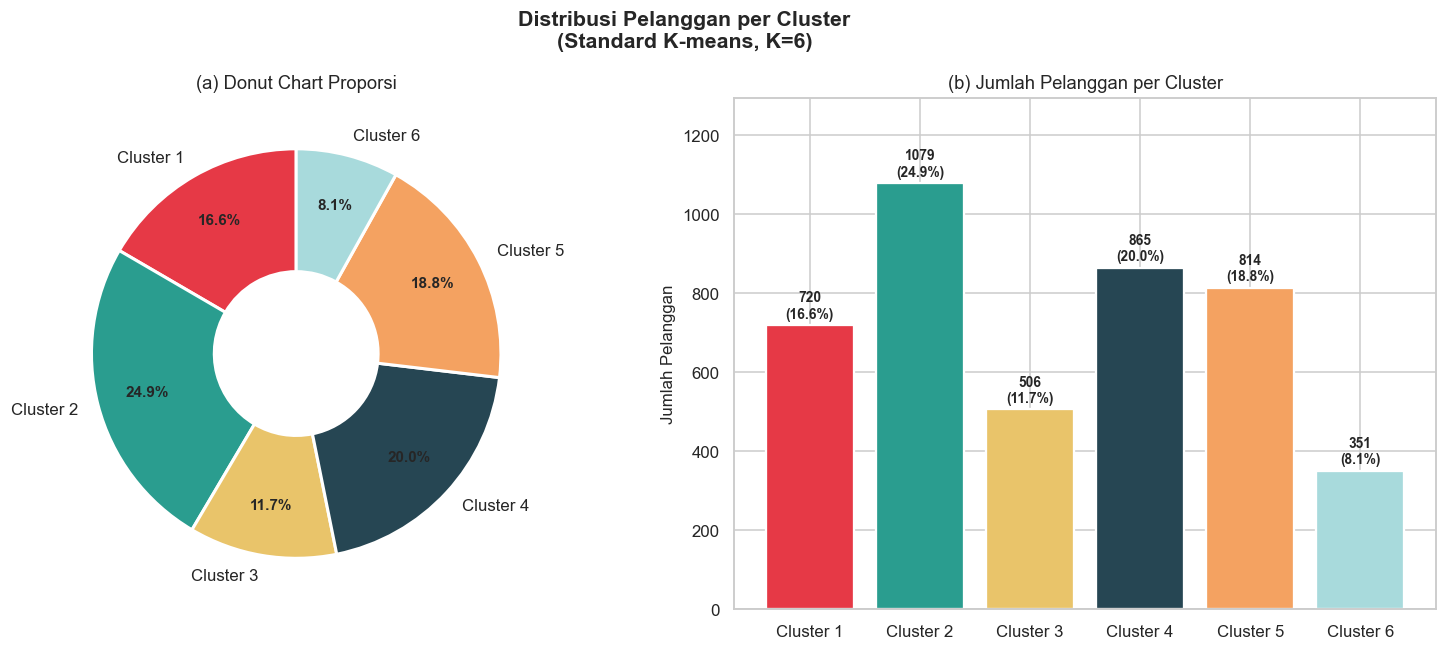

In [29]:
# ============================================================
# Visualisasi 2: Proporsi Pelanggan per Cluster
# Mereplikasi Fig 10 paper
# ============================================================
cluster_counts = pd.Series(model.labels_).value_counts().sort_index()
cluster_pcts   = cluster_counts / cluster_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Pelanggan per Cluster\n(Standard K-means, K=6)', fontsize=14, fontweight='bold')

# Pie Chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    cluster_counts.values,
    labels=[f'Cluster {c+1}' for c in cluster_counts.index],
    colors=CLUSTER_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('(a) Donut Chart Proporsi', fontsize=12)

# Bar Chart
ax = axes[1]
bars = ax.bar(
    [f'Cluster {c+1}' for c in cluster_counts.index],
    cluster_counts.values,
    color=CLUSTER_COLORS,
    edgecolor='white', linewidth=1.5
)
for bar, cnt, pct in zip(bars, cluster_counts.values, cluster_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('(b) Jumlah Pelanggan per Cluster', fontsize=12)
ax.set_ylabel('Jumlah Pelanggan')
ax.set_ylim(0, cluster_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('../models/cluster_distribution_kmeans.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Visualisasi 3D pada 3 PC Pertama (Fig 11 Paper)

Paper (Fig 11) memvisualisasikan hasil clustering pada ruang 3 principal component pertama.

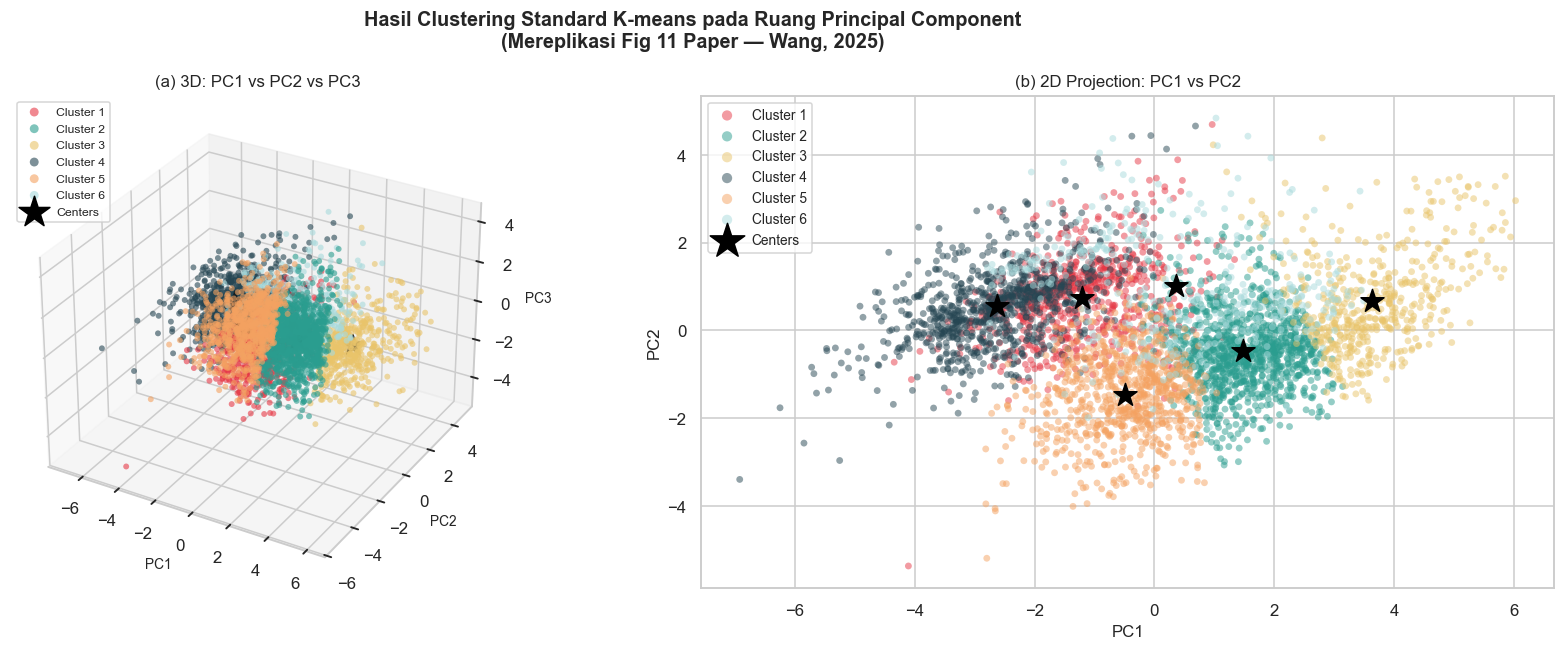

In [30]:
# ============================================================
# Visualisasi 3: Scatter Plot 3D pada PC1, PC2, PC3
# Mereplikasi Fig 11 paper
# ============================================================
labels = model.labels_

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Hasil Clustering Standard K-means pada Ruang Principal Component\n'
             '(Mereplikasi Fig 11 Paper — Wang, 2025)',
             fontsize=13, fontweight='bold')

# ── Panel 1: 3D scatter PC1 vs PC2 vs PC3 ──
ax1 = fig.add_subplot(121, projection='3d')
for c in range(K_OPTIMAL):
    mask = labels == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                c=CLUSTER_COLORS[c], label=f'Cluster {c+1}',
                s=15, alpha=0.6, edgecolors='none')

# Plot cluster centers
centers_2d = model.cluster_centers_
ax1.scatter(centers_2d[:, 0], centers_2d[:, 1], centers_2d[:, 2],
            c='black', marker='*', s=200, zorder=10, label='Centers')

ax1.set_xlabel('PC1', fontsize=9)
ax1.set_ylabel('PC2', fontsize=9)
ax1.set_zlabel('PC3', fontsize=9)
ax1.set_title('(a) 3D: PC1 vs PC2 vs PC3', fontsize=11)
ax1.legend(loc='upper left', fontsize=8, markerscale=1.5)

# ── Panel 2: 2D scatter PC1 vs PC2 ──
ax2 = fig.add_subplot(122)
for c in range(K_OPTIMAL):
    mask = labels == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=CLUSTER_COLORS[c], label=f'Cluster {c+1}',
                s=20, alpha=0.5, edgecolors='none')

ax2.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='black', marker='*', s=250, zorder=10, label='Centers')

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('(b) 2D Projection: PC1 vs PC2', fontsize=11)
ax2.legend(fontsize=9, markerscale=1.5)

plt.tight_layout()
plt.savefig('../models/cluster_3d_scatter_kmeans.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.4 Analisis Cluster Centers — Radar & Bar Chart (Fig 12 Paper)

Paper (Fig 12) menampilkan *ranking* nilai cluster centers di 11 fitur untuk mengidentifikasi karakteristik tiap cluster.

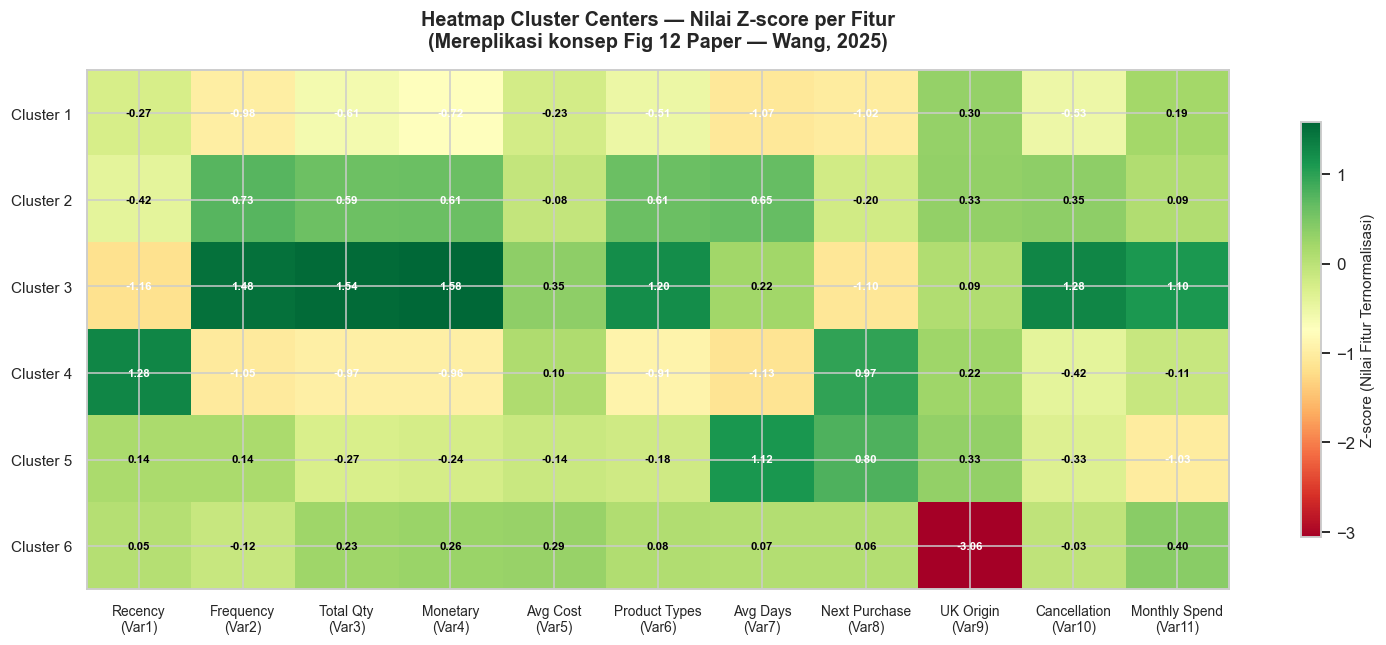


Cluster Centers (Z-score):
            Var1   Var2   Var3   Var4   Var5   Var6   Var7   Var8   Var9  Var10  Var11
Cluster 1 -0.267 -0.978 -0.609 -0.725 -0.229 -0.508 -1.067 -1.019  0.298 -0.530  0.191
Cluster 2 -0.424  0.735  0.588  0.611 -0.080  0.609  0.649 -0.204  0.327  0.349  0.088
Cluster 3 -1.161  1.478  1.541  1.582  0.351  1.204  0.216 -1.100  0.092  1.276  1.097
Cluster 4  1.277 -1.048 -0.971 -0.961  0.101 -0.906 -1.129  0.970  0.225 -0.417 -0.106
Cluster 5  0.139  0.136 -0.268 -0.243 -0.140 -0.178  1.119  0.797  0.327 -0.330 -1.027
Cluster 6  0.054 -0.116  0.234  0.259  0.289  0.081  0.069  0.064 -3.061 -0.034  0.397


In [31]:
# ============================================================
# Visualisasi 4: Heatmap Cluster Centers (11 fitur, Z-score)
# Mereplikasi konsep Fig 12 paper
# ============================================================

# Hitung cluster centers pada scaled data (11 fitur)
feature_cols = [f'Var{i}' for i in range(1, 12)]
feature_desc = [
    'Recency\n(Var1)', 'Frequency\n(Var2)', 'Total Qty\n(Var3)',
    'Monetary\n(Var4)', 'Avg Cost\n(Var5)', 'Product Types\n(Var6)',
    'Avg Days\n(Var7)', 'Next Purchase\n(Var8)', 'UK Origin\n(Var9)',
    'Cancellation\n(Var10)', 'Monthly Spend\n(Var11)'
]

# Cluster centers pada fitur Z-score
centers_df = df_scaled.groupby('Cluster')[feature_cols].mean()
centers_df.index = [f'Cluster {i+1}' for i in centers_df.index]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(centers_df.values, cmap='RdYlGn', aspect='auto',
               vmin=centers_df.values.min(), vmax=centers_df.values.max())

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Z-score (Nilai Fitur Ternormalisasi)', fontsize=10)

ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_desc, fontsize=9)
ax.set_yticks(range(len(centers_df)))
ax.set_yticklabels(centers_df.index, fontsize=10)

# Nilai pada sel
for i in range(len(centers_df)):
    for j in range(len(feature_cols)):
        val = centers_df.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=color, fontweight='bold')

ax.set_title('Heatmap Cluster Centers — Nilai Z-score per Fitur\n'
             '(Mereplikasi konsep Fig 12 Paper — Wang, 2025)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../models/cluster_centers_heatmap_kmeans.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCluster Centers (Z-score):')
print(centers_df.round(3).to_string())

### 5.5 Radar Chart — Profil 6 Cluster

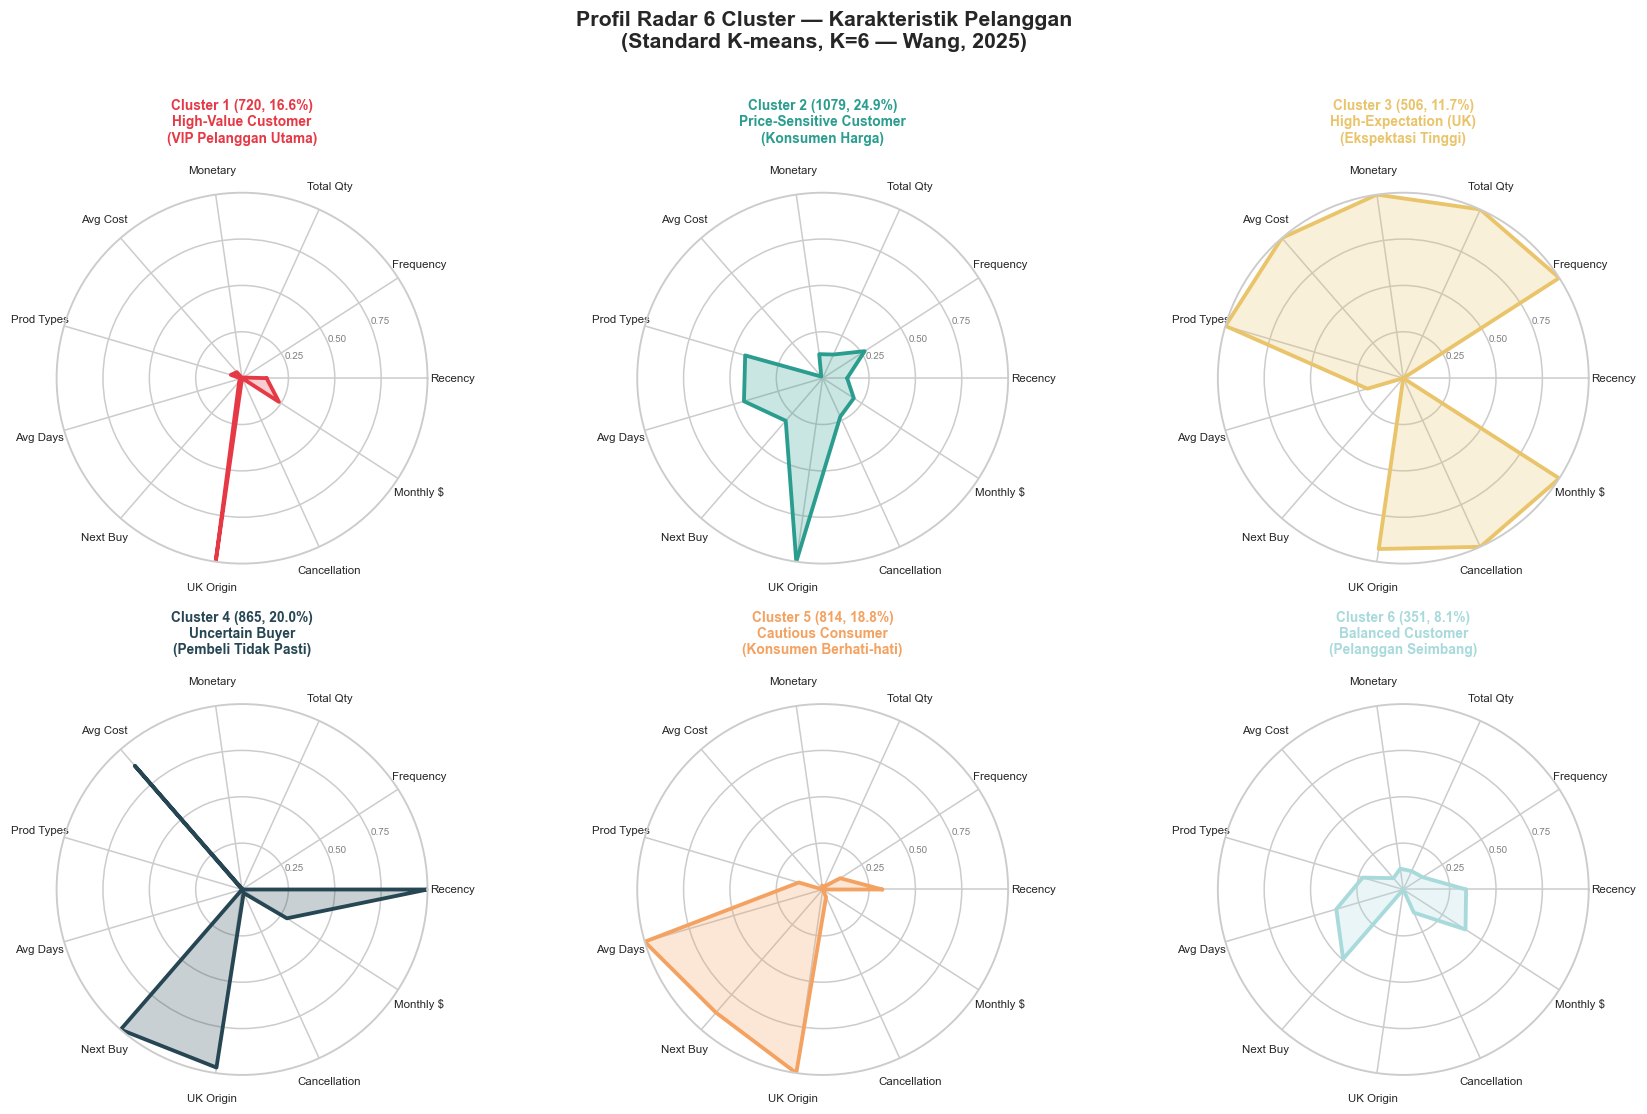

In [32]:
# ============================================================
# Visualisasi 5: Radar Chart (Spider Plot) tiap cluster
# ============================================================

# Gunakan nilai mentah (raw) ternormalisasi ke [0,1] untuk radar
centers_raw = df_raw.groupby('Cluster')[feature_cols].mean()
centers_raw.index = [f'Cluster {i+1}' for i in centers_raw.index]

# Min-max normalize cluster centers untuk tampilan radar
from sklearn.preprocessing import MinMaxScaler
scaler_mm = MinMaxScaler()
centers_norm = pd.DataFrame(
    scaler_mm.fit_transform(centers_raw.values),
    index=centers_raw.index,
    columns=feature_cols
)

# Short labels untuk radar
radar_labels = ['Recency', 'Frequency', 'Total Qty', 'Monetary', 'Avg Cost',
                'Prod Types', 'Avg Days', 'Next Buy', 'UK Origin', 'Cancellation', 'Monthly $']

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(2, 3, figsize=(16, 10), subplot_kw=dict(polar=True))
fig.suptitle('Profil Radar 6 Cluster — Karakteristik Pelanggan\n'
             '(Standard K-means, K=6 — Wang, 2025)',
             fontsize=14, fontweight='bold', y=1.01)

cluster_profiles = [
    ('Cluster 1', 'High-Value Customer\n(VIP Pelanggan Utama)'),
    ('Cluster 2', 'Price-Sensitive Customer\n(Konsumen Harga)'),
    ('Cluster 3', 'High-Expectation (UK)\n(Ekspektasi Tinggi)'),
    ('Cluster 4', 'Uncertain Buyer\n(Pembeli Tidak Pasti)'),
    ('Cluster 5', 'Cautious Consumer\n(Konsumen Berhati-hati)'),
    ('Cluster 6', 'Balanced Customer\n(Pelanggan Seimbang)'),
]

for ax, (cname, profile), color in zip(axes.flatten(), cluster_profiles, CLUSTER_COLORS):
    values = centers_norm.loc[cname].values.tolist()
    values += values[:1]  # close the loop
    
    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=6.5, color='gray')
    
    cnt = (df_pca['Cluster'] == int(cname.split()[-1]) - 1).sum()
    pct = cnt / len(df_pca) * 100
    ax.set_title(f'{cname} ({cnt}, {pct:.1f}%)\n{profile}',
                 fontsize=9, fontweight='bold', color=color, pad=15)

plt.tight_layout()
plt.savefig('../models/cluster_radar_kmeans.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Evaluasi Kualitas Clustering (Metrik)

Mengevaluasi hasil clustering Standard K-means menggunakan beberapa metrik:

| Metrik | Keterangan | Ideal |
|--------|-----------|-------|
| **SSE / Inertia** | Sum of Squared Errors (Persamaan 2) | Kecil |
| **Silhouette Score** | Kohesi vs. separasi cluster | Mendekati 1 |
| **Davies-Bouldin Index** | Ratio intra-cluster vs inter-cluster distance | Kecil |
| **Calinski-Harabasz Index** | Ratio dispersi antar- vs intra-cluster | Besar |

In [33]:
# ============================================================
# Evaluasi Metrik Clustering
# ============================================================
labels = model.labels_

sse     = model.inertia_
sil     = silhouette_score(X_pca, labels)
db      = davies_bouldin_score(X_pca, labels)
ch      = calinski_harabasz_score(X_pca, labels)

print('=' * 55)
print('  EVALUASI KUALITAS CLUSTERING — Standard K-means (K=6)')
print('=' * 55)
print(f'  SSE (Inertia)          : {sse:>15,.2f}  ↓ (kecil = baik)')
print(f'  Silhouette Score       : {sil:>15.4f}  ↑ (mendekati 1 = baik)')
print(f'  Davies-Bouldin Index   : {db:>15.4f}  ↓ (kecil = baik)')
print(f'  Calinski-Harabasz Index: {ch:>15.2f}  ↑ (besar = baik)')
print('=' * 55)

# Simpan metrik untuk perbandingan nanti
results_kmeans = {
    'Algorithm'  : 'Standard K-means (Paper)',
    'SSE'        : sse,
    'Silhouette' : sil,
    'Davies-Bouldin': db,
    'Calinski-Harabasz': ch,
    'K'          : K_OPTIMAL
}

# 1. Pastikan direktori tujuan sudah ada sebelum menyimpan
os.makedirs('../models', exist_ok=True)

# 2. Eksekusi penyimpanan array
np.save('../models/kmeans-standard_inertia.npy', np.array(sse))
np.save('../models/kmeans-standard_silhouette.npy', np.array(sil))
np.save('../models/kmeans-standard_db_score.npy', np.array(db))
np.save('../models/kmeans-standard_ch_score.npy', np.array(ch))
np.save('../models/kmeans-standard_runtime.npy', np.array(t_elapsed))
# np.save('../models/kmeans-standard_convergence.npy', np.array(qlde.convergence_curve_))

print('\nHasil disimpan untuk perbandingan dengan algoritma lain.')

  EVALUASI KUALITAS CLUSTERING — Standard K-means (K=6)
  SSE (Inertia)          :       19,459.09  ↓ (kecil = baik)
  Silhouette Score       :          0.2135  ↑ (mendekati 1 = baik)
  Davies-Bouldin Index   :          1.4795  ↓ (kecil = baik)
  Calinski-Harabasz Index:         1162.99  ↑ (besar = baik)

Hasil disimpan untuk perbandingan dengan algoritma lain.


## 4. Analisis Karakteristik Cluster (Interpretasi Bisnis)

Menganalisis karakteristik tiap cluster berdasarkan nilai rata-rata fitur (sesuai Fig 12 dan Section 4.2 paper).

In [34]:
# ============================================================
# Analisis Karakteristik Cluster
# ============================================================
feature_desc_short = {
    'Var1'  : 'Recency (hari sejak transaksi terakhir)',
    'Var2'  : 'Frequency (jumlah transaksi)',
    'Var3'  : 'Total produk dibeli',
    'Var4'  : 'Monetary (total pengeluaran)',
    'Var5'  : 'Rata-rata biaya per transaksi',
    'Var6'  : 'Jumlah tipe produk',
    'Var7'  : 'Rata-rata hari antar pembelian',
    'Var8'  : 'Perkiraan hari pembelian berikutnya',
    'Var9'  : 'Asal UK (0/1)',
    'Var10' : 'Frekuensi pembatalan',
    'Var11' : 'Rata-rata pengeluaran bulanan',
}

centers_raw_display = df_raw.groupby('Cluster')[feature_cols].mean().round(2)
centers_raw_display.index = [f'Cluster {i+1}' for i in centers_raw_display.index]
centers_raw_display.columns = [f'{v} ({feature_desc_short[v][:25]}...)' if len(feature_desc_short[v]) > 25
                                else f'{v} ({feature_desc_short[v]})'
                                for v in feature_cols]

# Deskripsi cluster sesuai paper Section 4.2
cluster_descriptions = {
    'Cluster 1': '🏆 HIGH-VALUE (VIP) — Pengeluaran bulanan tinggi, produk terbanyak, cancellation rendah.\n'
                 '   → Kelompok terpenting bagi perusahaan (revenue terbesar). Perlu program loyalitas eksklusif.',
    'Cluster 2': '💰 PRICE-SENSITIVE — Volume pembelian tinggi tapi frequency & spending rendah.\n'
                 '   → Konsumen rasional/hemat. Strategi: promo diskon, bundle harga.',
    'Cluster 3': '🇬🇧 HIGH-EXPECTATION (UK) — Mayoritas pelanggan UK, cancellation sedang.\n'
                 '   → Ekspektasi tinggi pada kualitas produk. Strategi: klarifikasi info produk.',
    'Cluster 4': '❓ UNCERTAIN BUYER — Cancellation tinggi, berasal dari non-UK.\n'
                 '   → Tidak pasti dalam keputusan pembelian. Strategi: optimalkan proses pembayaran.',
    'Cluster 5': '🤔 CAUTIOUS CONSUMER — Recency tinggi, frekuensi rendah, berhati-hati.\n'
                 '   → Banyak pertimbangan sebelum beli. Strategi: promosi akhir pekan, ulasan produk.',
    'Cluster 6': '⚖️  BALANCED CUSTOMER — Performa seimbang di semua indikator.\n'
                 '   → Tanpa preferensi ekstrem. Strategi: marketing diversifikasi.',
}

print('=' * 70)
print('  KARAKTERISTIK 6 CLUSTER — Standard K-means')
print('  Referensi: Section 4.2, Fig 12 — Wang (2025)')
print('=' * 70)

for c_name, desc in cluster_descriptions.items():
    c_idx = int(c_name.split()[-1]) - 1
    cnt   = (df_pca['Cluster'] == c_idx).sum()
    pct   = cnt / len(df_pca) * 100
    print(f'\n{c_name} — {cnt} pelanggan ({pct:.1f}%)')
    print(f'  {desc}')

  KARAKTERISTIK 6 CLUSTER — Standard K-means
  Referensi: Section 4.2, Fig 12 — Wang (2025)

Cluster 1 — 720 pelanggan (16.6%)
  🏆 HIGH-VALUE (VIP) — Pengeluaran bulanan tinggi, produk terbanyak, cancellation rendah.
   → Kelompok terpenting bagi perusahaan (revenue terbesar). Perlu program loyalitas eksklusif.

Cluster 2 — 1079 pelanggan (24.9%)
  💰 PRICE-SENSITIVE — Volume pembelian tinggi tapi frequency & spending rendah.
   → Konsumen rasional/hemat. Strategi: promo diskon, bundle harga.

Cluster 3 — 506 pelanggan (11.7%)
  🇬🇧 HIGH-EXPECTATION (UK) — Mayoritas pelanggan UK, cancellation sedang.
   → Ekspektasi tinggi pada kualitas produk. Strategi: klarifikasi info produk.

Cluster 4 — 865 pelanggan (20.0%)
  ❓ UNCERTAIN BUYER — Cancellation tinggi, berasal dari non-UK.
   → Tidak pasti dalam keputusan pembelian. Strategi: optimalkan proses pembayaran.

Cluster 5 — 814 pelanggan (18.8%)
  🤔 CAUTIOUS CONSUMER — Recency tinggi, frekuensi rendah, berhati-hati.
   → Banyak pertimbangan

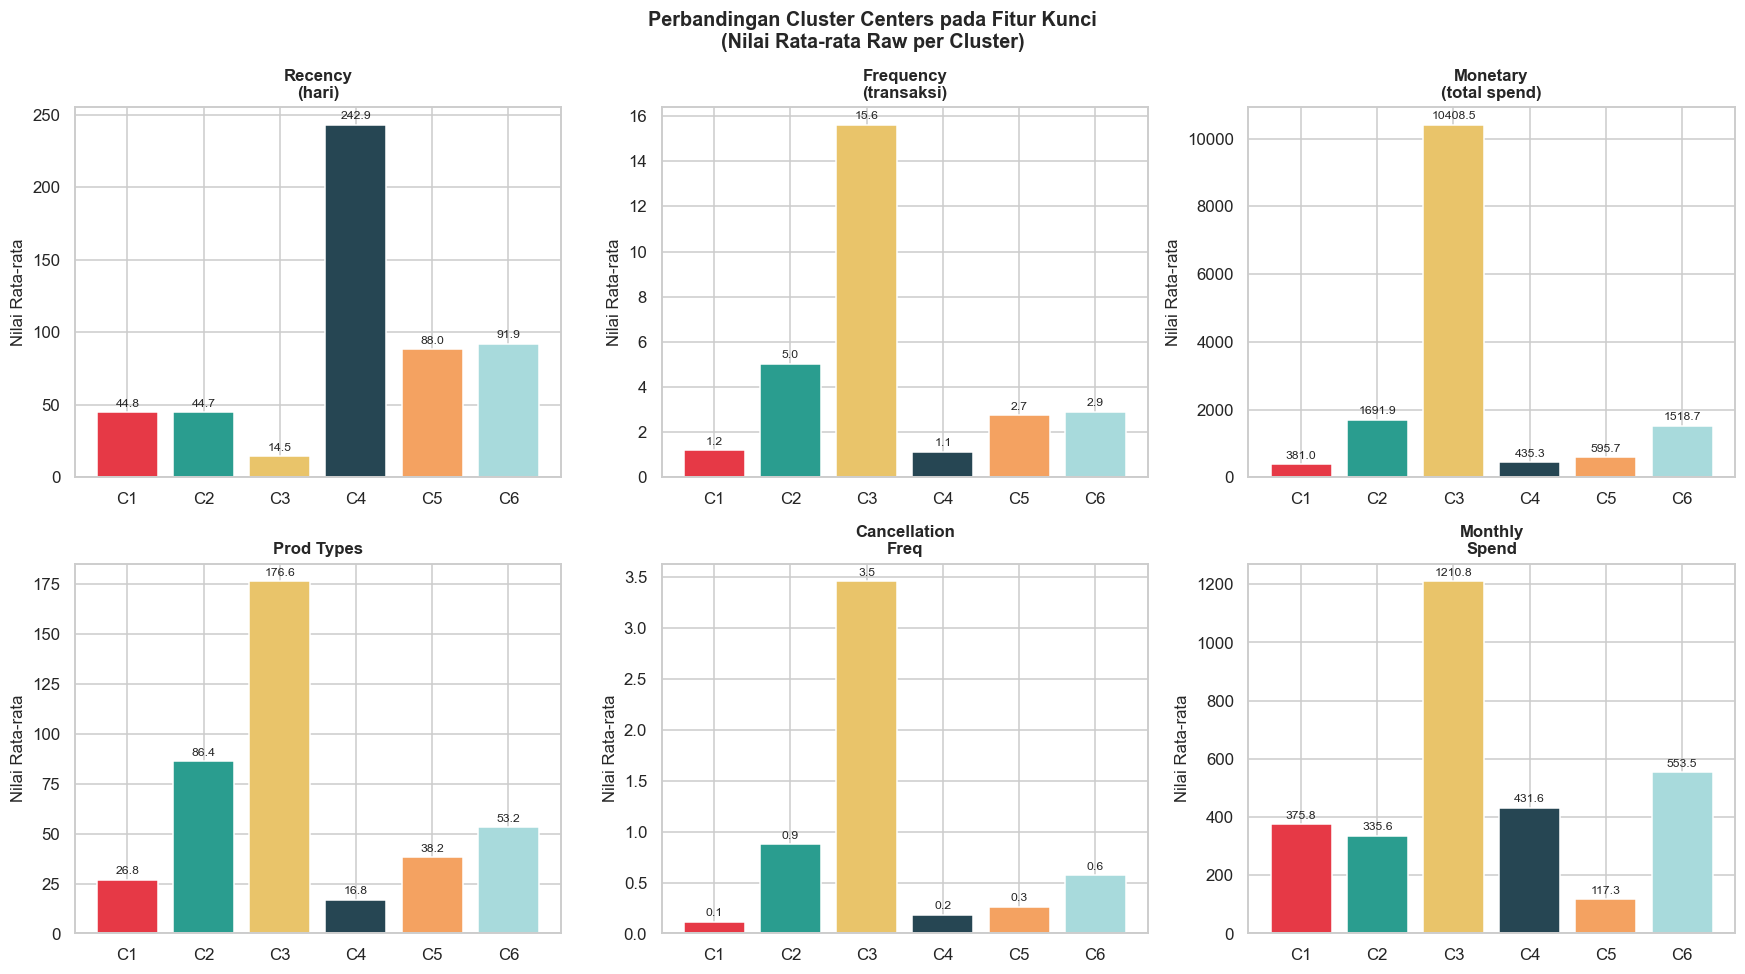

In [35]:
# ============================================================
# Visualisasi 6: Bar Chart Perbandingan Cluster Centers (Raw)
# ============================================================
centers_raw_plot = df_raw.groupby('Cluster')[feature_cols].mean()
centers_raw_plot.index = [f'Cluster {i+1}' for i in centers_raw_plot.index]

# Pilih fitur paling informatif untuk perbandingan
key_features = ['Var1', 'Var2', 'Var4', 'Var6', 'Var10', 'Var11']
key_labels   = ['Recency\n(hari)', 'Frequency\n(transaksi)', 'Monetary\n(total spend)',
                'Prod Types', 'Cancellation\nFreq', 'Monthly\nSpend']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Perbandingan Cluster Centers pada Fitur Kunci\n'
             '(Nilai Rata-rata Raw per Cluster)',
             fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flatten(), key_features, key_labels):
    vals = centers_raw_plot[feat].values
    bars = ax.bar(
        [f'C{i+1}' for i in range(K_OPTIMAL)],
        vals,
        color=CLUSTER_COLORS,
        edgecolor='white', linewidth=1
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai Rata-rata')
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../models/cluster_features_comparison_kmeans.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Simpan Hasil Clustering

In [36]:
# Dataset berlabel
df_labeled = df_raw.copy()
df_labeled['Cluster_kmeans_standard'] = labels

# Tambahkan Label Bisnis
df_labeled['Label_Bisnis'] = df_labeled['Cluster_kmeans_standard'].map({
    0: 'HIGH-VALUE (VIP)',
    1: 'PRICE-SENSITIVE',
    2: 'HIGH-EXPECTATION (UK)',
    3: 'UNCERTAIN BUYER',
    4: 'CAUTIOUS CONSUMER',
    5: 'BALANCED CUSTOMER'
})

df_labeled.to_csv('../data/Labeled/hasildata_kmeans-standard.csv')
print('File berhasil disimpan: ../data/Labeled/hasildata_kmeans-standard.csv')



File berhasil disimpan: ../data/Labeled/hasildata_kmeans-standard.csv


**Referensi Algoritma (Standard K-Means & RFM):**
* Sarvari, P. A., Ustundag, A., & Takci, H. (2016). *Performance evaluation of different customer segmentation approaches based on RFM and demographics analysis*. Kybernetes, 45(7), 1129-1157. (Terdapat pada `references/Peiman_Emerald.pdf`)
